# 01 - AEMO Data: Understanding Every Feature


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.config import DATA_RAW

pd.set_option("display.max_columns", None)

FILENAME = "PRICE_AND_DEMAND_202608_QLD1.csv"

raw = pd.read_csv(DATA_RAW / FILENAME)

print("Rows:", len(raw))
print("Columns:", list(raw.columns))

Rows: 1728
Columns: ['REGION', 'SETTLEMENTDATE', 'TOTALDEMAND', 'RRP', 'PERIODTYPE']


## First look - untouched



In [2]:
raw.head()

,REGION,SETTLEMENTDATE,TOTALDEMAND,RRP,PERIODTYPE
0,QLD1,2026/08/01 00:05:00,6053.26,75.30,TRADE
1,QLD1,2026/08/01 00:10:00,6038.46,79.61,TRADE
2,QLD1,2026/08/01 00:15:00,5977.62,73.92,TRADE
3,QLD1,2026/08/01 00:20:00,5931.32,72.07,TRADE
4,QLD1,2026/08/01 00:25:00,5900.98,69.35,TRADE


In [3]:
raw.dtypes

REGION                str
SETTLEMENTDATE        str
TOTALDEMAND       float64
RRP               float64
PERIODTYPE            str
dtype: object

**Which columns did pandas guess wrongly?**

*Four columns were guessed correctly. SETTLEMENTDATE was not - it was read as text, but it is a date and time.*

---
# Feature 1 - REGION

A column with one repeated value carries no information. Checking before keeping it.

In [4]:
raw["REGION"].value_counts()

REGION
QLD1    1728
Name: count, dtype: int64

**How many different values? Keep this column or drop it?**

*One value only - QLD1. A column that never changes carries no information, so drop it.*

---
# Feature 2 - PERIODTYPE

In [5]:
raw["PERIODTYPE"].value_counts()

PERIODTYPE
TRADE    1728
Name: count, dtype: int64

**Does it vary? If not, it tells you nothing — drop it.**

*One value only - TRADE. A column that never changes carries no information, so drop it.*

---
# Feature 3 - SETTLEMENTDATE

The most important column. Four things to check: type, interval, duplicates, gaps.

In [6]:
df = raw.copy()
df["SETTLEMENTDATE"] = pd.to_datetime(df["SETTLEMENTDATE"])
df = df.sort_values("SETTLEMENTDATE").reset_index(drop=True)

print("First:", df["SETTLEMENTDATE"].min())
print("Last: ", df["SETTLEMENTDATE"].max())
print("Span: ", df["SETTLEMENTDATE"].max() - df["SETTLEMENTDATE"].min())

First: 2026-08-01 00:05:00
Last:  2026-08-07 00:00:00
Span:  5 days 23:55:00


### Interval 

`.diff()` gives the gap between each row and the one before.
`.value_counts()` shows how often each gap size appears.

In [7]:
df["SETTLEMENTDATE"].diff().value_counts()

SETTLEMENTDATE
0 days 00:05:00    1727
Name: count, dtype: int64

**What is the interval? Any unexpected gap sizes?**

*5 minutes, and only 5 minutes — 1,727 gaps, all identical. No unexpected sizes, so no missing rows.*

*(1,727 not 1,728 because the first row has nothing before it to compare against.)*

### Duplicates

In [8]:
dupes = df["SETTLEMENTDATE"].duplicated().sum()
print("Duplicate timestamps:", dupes)

Duplicate timestamps: 0


### Missing rows

Build the timestamps *expected*, then subtract the ones we *have*.
Comparing against an expected structure is more reliable than looking.

In [11]:
expected = pd.date_range(df["SETTLEMENTDATE"].min(),
                         df["SETTLEMENTDATE"].max(),
                         freq="5min")
actual = pd.DatetimeIndex(df["SETTLEMENTDATE"])
missing = expected.difference(actual)

print("Expected:", len(expected))
print("Actual:  ", len(actual))
print("Missing: ", len(missing))

Expected: 1728
Actual:   1728
Missing:  0


### Where are the gaps?



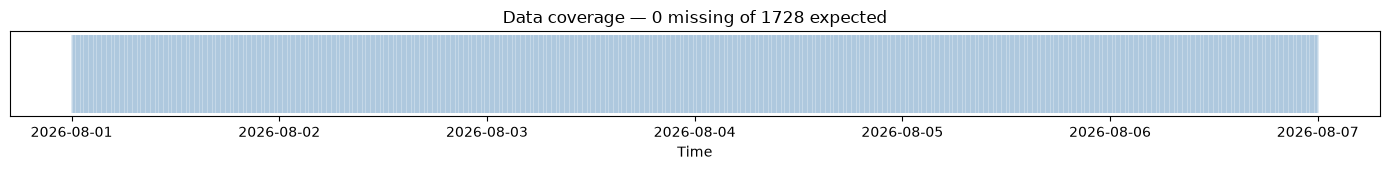

In [12]:
fig, ax = plt.subplots(figsize=(14, 1.8))

ax.vlines(actual, 0, 1, color="steelblue", linewidth=0.25)
if len(missing):
    ax.vlines(missing, 0, 1, color="red", linewidth=2)

ax.set_yticks([])
ax.set_title(f"Data coverage — {len(missing)} missing of {len(expected)} expected")
ax.set_xlabel("Time")
plt.tight_layout()
plt.show()

**Scattered or clumped? If clumped, what might have happened then?**

*Neither - there are no gaps to be scattered or clumped. 1,728 expected, 1,728 found.*

---
# Feature 4 - TOTALDEMAND



In [13]:
df["TOTALDEMAND"].describe()

count    1728.000000
mean     5935.075341
std      1035.676252
min      3807.190000
25%      5303.150000
50%      5863.445000
75%      6839.192500
max      7866.150000
Name: TOTALDEMAND, dtype: float64

### Shape of the distribution

A histogram shows where the values sit. The vertical lines mark the median and
the 5th and 95th percentiles, so the typical range is visible at a glance.

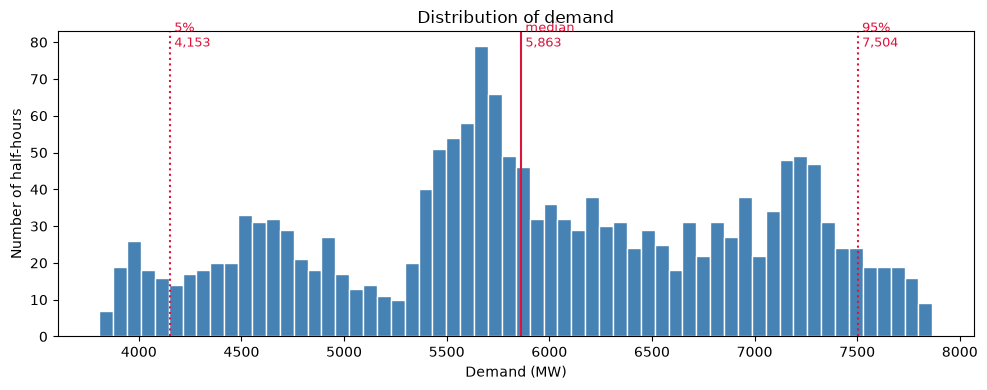

In [14]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(df["TOTALDEMAND"], bins=60, color="steelblue", edgecolor="white")

for q, style, label in [(0.05, ":", "5%"), (0.5, "-", "median"), (0.95, ":", "95%")]:
    v = df["TOTALDEMAND"].quantile(q)
    ax.axvline(v, color="crimson", linestyle=style, linewidth=1.5)
    ax.text(v, ax.get_ylim()[1] * 0.95, f" {label}\n {v:,.0f}", color="crimson", fontsize=9)

ax.set_xlabel("Demand (MW)")
ax.set_ylabel("Number of half-hours")
ax.set_title("Distribution of demand")
plt.tight_layout()
plt.show()

**Is the shape symmetric, or leaning to one side? What does that tell you about
how often Queensland runs near its peak?**

*Not symmetric, and not one hump - there are two. A tall peak near 5,600 MW and a second smaller one near 7,200 MW, with a dip between.*

*Two peaks means two different situations mixed into one chart: the quiet hours and the evening peak. Demand doesn't drift around one average it sits in one of two regimes.*

*90% of the time demand is between 4,153 and 7,504 MW. Queensland rarely runs near its maximum.*

### Demand over time

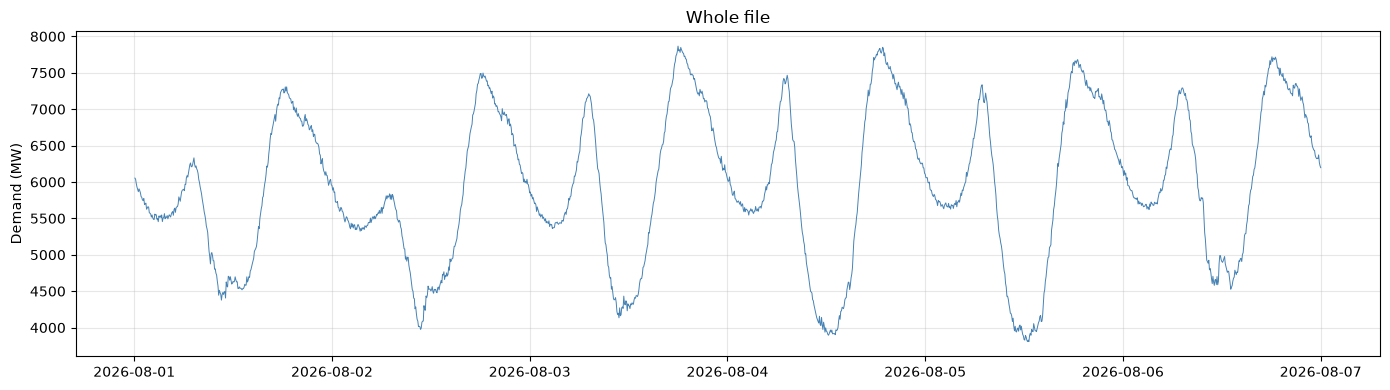

In [15]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df["SETTLEMENTDATE"], df["TOTALDEMAND"], linewidth=0.7, color="steelblue")
ax.set_ylabel("Demand (MW)")
ax.set_title("Whole file")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### The daily shape - every day at once

Plot every single day faintly on top of each other, with the median in red.

This shows two things a normal line plot hides: the shape of a typical day, and how
much days differ from each other. Where the grey lines spread wide, demand is
unpredictable at that hour.

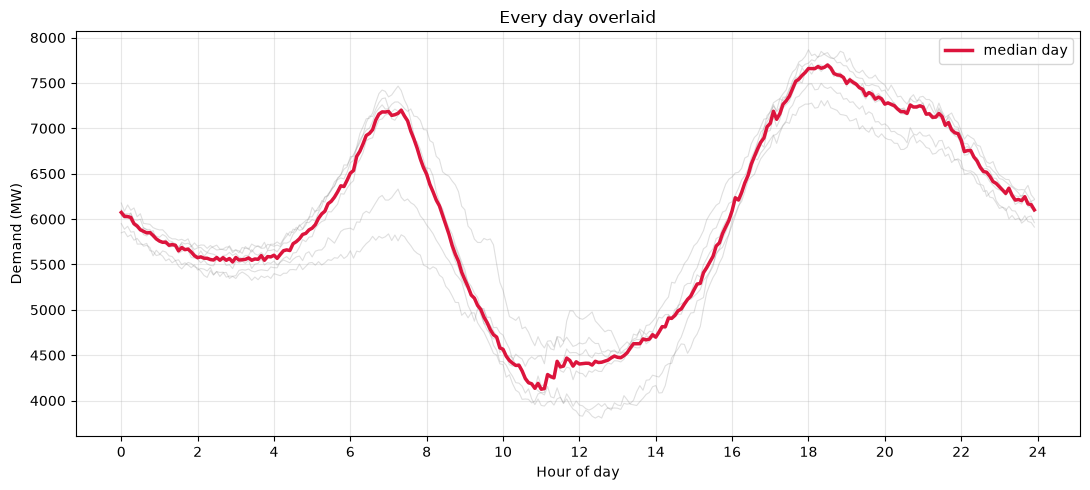

In [16]:
df["date"] = df["SETTLEMENTDATE"].dt.date
df["hour_dec"] = df["SETTLEMENTDATE"].dt.hour + df["SETTLEMENTDATE"].dt.minute / 60

fig, ax = plt.subplots(figsize=(11, 5))

for _, day in df.groupby("date"):
    ax.plot(day["hour_dec"], day["TOTALDEMAND"], color="grey", alpha=0.25, linewidth=0.8)

median = df.groupby("hour_dec")["TOTALDEMAND"].median()
ax.plot(median.index, median.values, color="crimson", linewidth=2.5, label="median day")

ax.set_xlabel("Hour of day")
ax.set_ylabel("Demand (MW)")
ax.set_xticks(range(0, 25, 2))
ax.set_title("Every day overlaid")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**When is demand highest? Lowest?**

*Two peaks: 7am (~7,200 MW) and 6pm (~7,700 MW). Lowest at 11am (~4,150 MW), which is lower than 3am.Midday being the quietest is the opposite of what I expected. TOTALDEMAND is power taken from the grid, and at midday rooftop solar supplies homes directly, so the grid sees less. This is the duck curve.*

**Timezone check:** does the peak land in the late afternoon or early evening, where
people actually use power? 

*Correct. The evening peak is at 6pm, exactly where human behaviour puts it. If the timezone were wrong the peak would sit somewhere implausible.*

**At which hours do the grey lines spread widest? Those are the hardest hours to predict.**

*Two places. Around 7am the lines fan out badly - a few days show a much smaller morning peak, probably weekends. And around 11am to 1pm they spread by roughly 1,000 MW, because that depends on cloud cover, which changes day to day.*

*Both are hardest to predict. The morning spread argues for a weekday/weekend feature. The midday spread argues for cloud cover as a weather feature.*

### Hour vs day of week

A heatmap of average demand: 24 hours down, 7 days across.

Darker means more demand. This shows the daily rhythm and the weekly rhythm in
one picture.

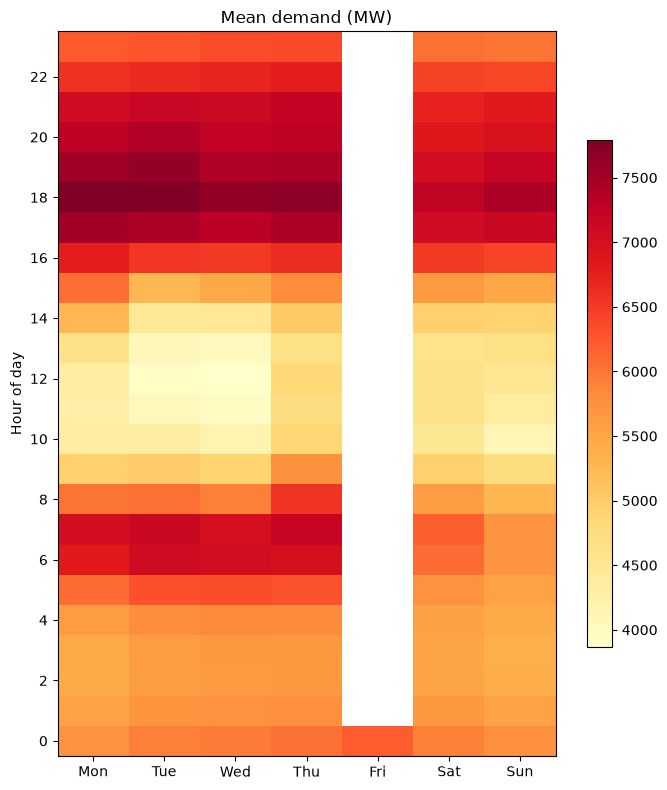

In [17]:
df["dow"] = df["SETTLEMENTDATE"].dt.dayofweek
df["hour"] = df["SETTLEMENTDATE"].dt.hour

grid = df.pivot_table(index="hour", columns="dow", values="TOTALDEMAND", aggfunc="mean")

fig, ax = plt.subplots(figsize=(7, 8))
im = ax.imshow(grid.values, aspect="auto", origin="lower", cmap="YlOrRd")

ax.set_xticks(range(7))
ax.set_xticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
ax.set_yticks(range(0, 24, 2))
ax.set_yticklabels(range(0, 24, 2))
ax.set_ylabel("Hour of day")
ax.set_title("Mean demand (MW)")

fig.colorbar(im, ax=ax, shrink=0.7)
plt.tight_layout()
plt.show()

**Are weekends different from weekdays? By roughly how much?**

*Slightly lower on weekends, mainly in the morning. The 6–8am block is clearly darker Mon–Thu than Sat–Sun, because weekdays have people getting up for work. The evening peak looks similar on both.*

**Which single hour of which day has the highest average demand?**

*Monday around 6pm, roughly 7,500 MW.*

**Does this convince you that hour-of-day and day-of-week should be model features?**

*Hour, definitely - the vertical banding is strong and consistent. Weekday, probably, but this file is only six days so I can't judge it properly. I'll re-check once I have a few months.*

*Friday is almost entirely blank because my file starts at 00:05 on Saturday 1 August and ends at midnight on Friday 7th. Only one row lands on a Friday. This isn't missing data, it's a six-day sample being forced into a seven-day grid.*



### Does the past predict the future?

Plot demand against demand from 1 day ago (288 rows back) and 1 hour ago (12 rows back).

At 5-minute intervals: 288 rows = 24 hours, 12 rows = 1 hour.
A 1-week lag would be 2016 rows, but this file is only 6 days, so there is not
enough overlap to test it here.

If the dots form a tight diagonal, the past is a strong predictor and lag features
will work. If they scatter, they won't. This is how you decide whether a feature is
worth building *before* you build it.

**Note:** my first attempt used 48 and 336 rows, which are correct for 30-minute data.
Mine is 5-minute, so those were really 4 hours and 28 hours. Correlation came out near
zero and the plot formed a loop - the daily cycle compared against itself at the wrong
offset. A wrong lag gives no error, just a plausible chart and a wrong conclusion.


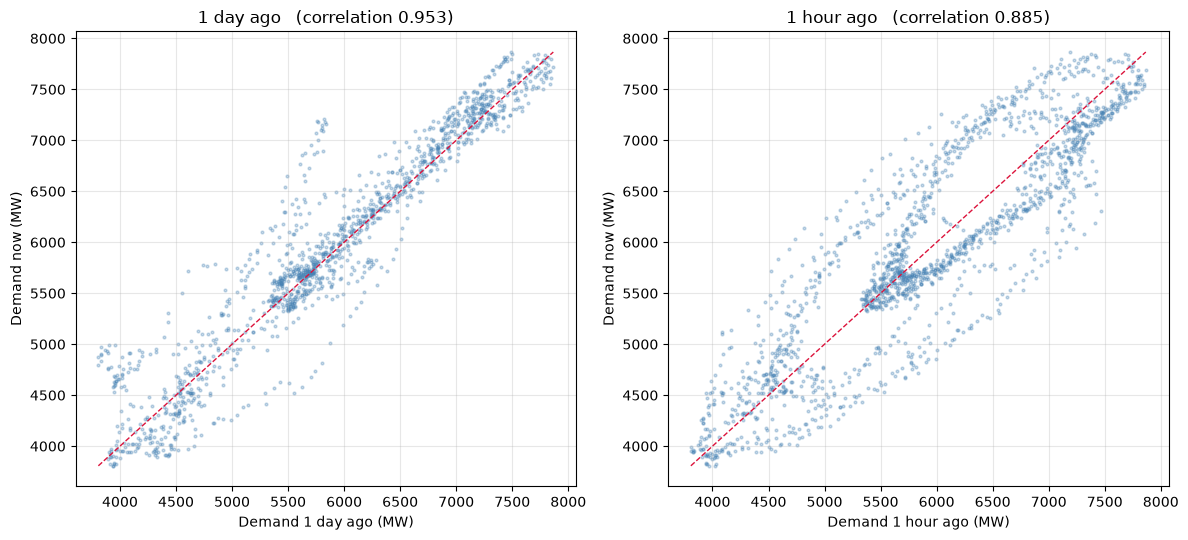

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

for ax, (lag, label) in zip(axes, [(288, "1 day ago"), (12, "1 hour ago")]):
    x = df["TOTALDEMAND"].shift(lag)
    y = df["TOTALDEMAND"]
    ax.scatter(x, y, s=4, alpha=0.3, color="steelblue")

    lo = df["TOTALDEMAND"].min()
    hi = df["TOTALDEMAND"].max()
    ax.plot([lo, hi], [lo, hi], color="crimson", linewidth=1, linestyle="--")

    corr = x.corr(y)
    ax.set_xlabel(f"Demand {label} (MW)")
    ax.set_ylabel("Demand now (MW)")
    ax.set_title(f"{label}   (correlation {corr:.3f})")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Which lag is the stronger predictor, and by how much?**

*Yesterday (0.953) beats an hour ago (0.885). Surprising - I'd expect the more recent value to win. But demand runs on a daily cycle, so the same clock time yesterday matches better than a different clock time today. An hour before 6pm is 5pm, and 5pm looks quite different. The useful lag is "same point in the cycle", not "most recent". Both are worth building.*

**The red line is where the dots would sit if the past predicted the future perfectly.
How far off are they?**

*Yesterday's cloud hugs the line closely, tightest at high demand where the evening peak is reliable. It widens around 4,500–5,500 MW — the midday solar region, the unpredictable part again.*

*The 1-hour plot fans into visible bands above and below the line. Those are morning (rising) and afternoon (falling) - same gap, opposite direction.*

---
# Feature 5 - RRP (price)



In [20]:
df["RRP"].describe()

count    1728.000000
mean       67.117020
std        46.384818
min       -25.010000
25%        39.950000
50%        65.395000
75%        98.950000
max       294.400000
Name: RRP, dtype: float64

In [21]:
negatives = (df["RRP"] < 0).sum()
print(f"Negative prices: {negatives} of {len(df)}  ({negatives/len(df)*100:.1f}%)")
print("Lowest: ", df["RRP"].min())
print("Highest:", df["RRP"].max())

Negative prices: 173 of 1728  (10.0%)
Lowest:  -25.01
Highest: 294.4


### When are prices negative?

Negative price means generators pay to keep supplying - usually too much solar on a
mild sunny day.

Plot mean price by hour, with negative hours in red.

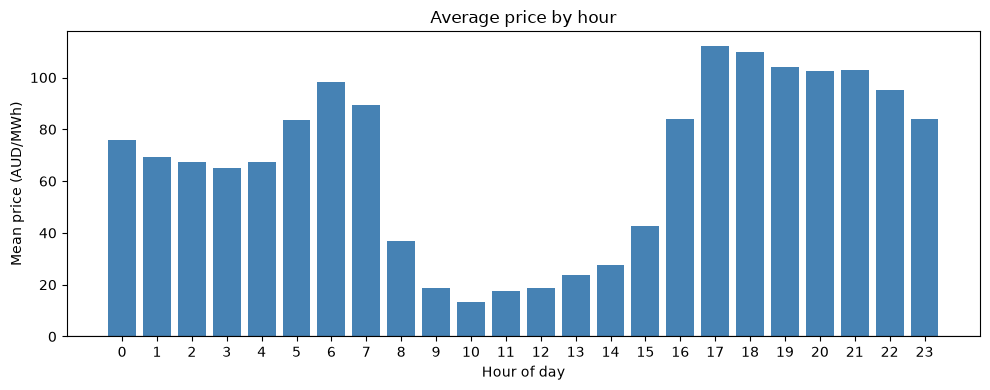

In [22]:
by_hour = df.groupby("hour")["RRP"].mean()
colours = ["crimson" if v < 0 else "steelblue" for v in by_hour.values]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(by_hour.index, by_hour.values, color=colours)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Hour of day")
ax.set_ylabel("Mean price (AUD/MWh)")
ax.set_title("Average price by hour")
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()

**At which hours is price lowest? Does that match when solar generates most?**

*Cheapest from 9am to 1pm, lowest at 10am (~$13). Most expensive at 5–6pm (~$113) - an eightfold difference within the same day.*

*Yes, it matches solar exactly. Peak sunshine floods the market with supply, so price collapses. As the sun drops, solar disappears just as people get home and switch things on - supply falls and demand rises together, so price spikes.*

*This is the same duck curve I saw in demand, measured a different way. Two independent columns telling the same story is good evidence the effect is real, not an artefact of six days of data.*

*No bars show red because the hourly average hides them - the 173 negative intervals are inside the midday bars but the mean stays positive.*

---
# Conclusions

| Question | Answer |
|---|---|
| Columns I will store | SETTLEMENTDATE (as UTC), TOTALDEMAND, RRP |
| Columns I will drop, and why | REGION (always QLD1) and PERIODTYPE (always TRADE) - a column that never changes carries no information |
| Interval | 5 minutes, perfectly consistent. 288 rows per day |
| Duplicates found | 0 |
| Missing rows found | 0 - 1,728 expected, 1,728 found |
| Timezone confirmed correct | Yes. Evening peak lands at 6pm, where human behaviour puts it |
| Features the plots suggest are worth building | Hour of day (strong banding in the heatmap); lag of 288 rows = 1 day (correlation 0.953); lag of 12 rows = 1 hour (0.885); weekday vs weekend (morning peak differs, but only 6 days of data so needs re-checking); cloud cover (midday spread is widest, and solar drives it) |

### Things that surprised me

1. Demand is lowest at 11am, not overnight. I expected 3am. TOTALDEMAND is power taken from the grid, and at midday rooftop solar supplies homes directly, so the grid sees less than it does at night. This is the duck curve. It means sunshine matters as much as temperature, and demand does not rise in a simple line with heat.

2. Yesterday predicts better than an hour ago (0.953 vs 0.885). The useful lag is "same point in the daily cycle", not "most recent".

3. Price swings eightfold within one day - $13 at 10am, $113 at 5pm. Negative 10% of the time. Same cause as the demand trough, measured differently. Two independent columns telling the same story is good evidence the effect is real.

4. My lag plot was wrong and gave no error. I used 48 and 336 rows, correct for 30-minute data, but mine is 5-minute - so those were 4 hours and 28 hours. Correlation came out near zero and the plot formed a loop. A wrong lag produces a plausible chart and a wrong conclusion, silently.

5. The heatmap's blank Friday column looked like broken data but wasn't. My file covers six days, so only one row lands on a Friday. A correct plot can still mislead if you don't check what's behind each cell.

6. Averaging hid the negative prices. They exist in 173 rows but no hourly bar goes below zero. Worth remembering when I evaluate models - a mean error can look fine while hiding the cases I care about.